<a href="https://colab.research.google.com/github/FREDONE/PHP-projects-and-codes-/blob/main/2026_04_07_lesson_6_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on Exercises for Lesson 6: Data Exploration, Transformation, and Visualization with LLMs

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/gist/nicomarr/fd6ff6efded5f4582928938722aa0f8b/2026-04-07-lesson-6-exercises.ipynb)

## About the Exercises

This notebook provides hands-on examples of using Python for data analysis tasks commonly encountered in biomedical research.

- **Exercise 1**: Perform matrix multiplication and dot product calculations using NumPy—fundamental operations underlying neural network computations and embedding-based similarity search (which we'll do in Exercise 4).
- **Exercise 2**: Apply dimensionality reduction (PCA) to visualize high-dimensional tabular data, a core technique for exploring datasets like bulk RNA-seq or, in this exercise, a [dataset with 30 features from breast tumor images for malignant vs benign classification](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).
- **Exercise 3**: Generate and visualize text embeddings using UMAP, the same algorithm widely used for single-cell RNA-seq analysis.
- **Exercise 4**: Perform similarity search on text embeddings to retrieve semantically related content from a collection of Q&A pairs.

### What you'll learn
- The advantages of vectorized computation for efficient data analysis
- How to use Python for tasks you may have previously done in R
- How to transform unstructured data (text) into structured representations (embeddings) for visualization and retrieval

### Where does the LLM come in?

LLMs can't perform matrix multiplication, run PCA, or compute cosine similarity by themselves — but they don't need to. Modern chat interfaces like Claude, ChatGPT, and Gemini include server-side code execution sandboxes with common data science libraries pre-installed. When you describe a task, the LLM writes and executes the code for you, returning results and plots directly in the conversation. In this course we'll use Claude's free tier, but the same workflow applies to other tools.

Beyond code execution, LLMs are useful here in three more ways:

1. **Understanding code:** Ask the LLM to explain what a helper function does, or what its parameters mean
2. **Modifying code:** Ask it to adapt a function for your own dataset or task
3. **Tool use:** The functions in these exercises can be packaged as tools that LLMs invoke programmatically (e.g., as [Agent Skills](https://agentskills.io/home)). We'll cover this in Lesson 7.

> **💡 What can you do with Claude Chat (free tier)?**
>
> Claude's Chat tab (at [claude.ai](https://claude.ai) or the Desktop app) includes a **server-side code sandbox** that can run Python and Node.js — no setup required. When you ask Claude to analyze data, write code, or create visualizations, it executes real code in a secure container and returns the results.
>
> **What's available out of the box (as of April 2026):**
> - **Python 3.12** with numpy, pandas, matplotlib, seaborn, scipy, scikit-learn, scikit-image, sympy, opencv, networkx, and Pillow pre-installed
> - **Node.js v22** for JavaScript tasks
> - **Document tools:** python-docx, python-pptx, openpyxl, reportlab, pdfplumber, and more for reading/writing Office and PDF files
>
> **Need something else?** You can ask Claude to `pip install` additional packages on the fly — the sandbox has access to PyPI and installs are fast. For example, `altair`, `umap-learn`, and `xgboost` all install and work without issues. Note that very large packages like PyTorch (~2GB) may be possible but will eat into the ~5GB disk limit.
>
> **Limitations to keep in mind:**
> - File uploads are capped at **30MB** per file (20 files per chat)
> - **No GPU** — ML and dimensionality reduction (t-SNE, UMAP) run on CPU only, which is fine for moderate datasets
> - **No arbitrary web access** — the sandbox can only reach package repositories (PyPI, npm, GitHub), not the open web. This means you can't fetch datasets from URLs like GitHub Gists or external APIs. Instead, upload your data files directly or use datasets built into libraries (e.g., `sklearn.datasets`)
> - **Usage limits** reset every ~5 hours, and the number of messages varies with demand
> - Conversations on the free plan may be used for model training (opt out in settings if available)
>
> **Stay up to date:** Check the [Release notes](https://support.claude.com/en/articles/12138966-release-notes) on the Claude support site for the latest on features and limitations.
>
> **Bottom line:** For coursework-level data exploration — loading CSVs, running PCA/t-SNE/UMAP, fitting sklearn models, plotting with matplotlib or altair — the free tier gives you a fully functional, zero-setup Python environment. Just describe what you want to do and the LLM will write and run the code for you.


## **Warmup:** Reveal the code execution capabilities with Claude Chat

Open the [Claude web app](https://claude.ai/) and copy and paste the following prompt to reveal what's available in the code execution sandbox. This will confirm that you have access to the necessary libraries for these exercises, and show you how to check versions and install new packages on the fly.

```Markdown
I'm taking a data science course and want to understand what my sandbox environment can do. Please do the following step by step:

1. Run `uname -a && python3 --version && node --version` and return the full output.
2. Run `pip list` and return only the pre-installed packages relevant to data science, machine learning, visualization, and numerical computing.
3. Run `pip install --dry-run umap-learn altair` and show what would be installed.
```

## Setup Jupyter Notebook environment (Google Colab or local)

Run the cell below to install the required packages. If you've already installed them, you can skip this step.

**Note:** Each exercise includes its own import statements, so you can run exercises independently or export individual code cells to your own notebooks. Helper functions are loaded from [this GitHub gist](https://gist.github.com/nicomarr/9445da5f2a1be55c406899ad3a5356a7/raw/embed_viz_utils.py)

In [ ]:
#@title Install dependencies { display-mode: "form" }
%pip install -q umap-learn altair cohere httpx # For Google Colab (avoids pandas version conflict)

# For local development, uncomment the line below instead:
# %pip install -qU numpy pandas scikit-learn umap-learn altair cohere matplotlib ipywidgets httpx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 29.7 MB/s eta 0:00:00


In [ ]:
#@title Load helper functions { display-mode: "form" }
import httpx, types
import types

def load_module_from_url(url: str, module_name: str = "embed_viz_utils") -> types.ModuleType:
    """Load a Python module from a URL."""
    response = httpx.get(url)
    response.raise_for_status()
    module = types.ModuleType(module_name)
    exec(response.text, module.__dict__)
    return module

UTILS_URL = "https://gist.githubusercontent.com/nicomarr/9445da5f2a1be55c406899ad3a5356a7/raw/embed_viz_utils.py"
embed_utils = load_module_from_url(UTILS_URL)

print("✓ Loaded: cosine_distance, find_closest_matches, visualize_embeddings")

✓ Loaded: cosine_distance, find_closest_matches, visualize_embeddings


In [ ]:
#@title Get Cohere API key from secrets { display-mode: "form" }
try: from google.colab import userdata; import os; os.environ.update({'COHERE_API_KEY': userdata.get('COHERE_API_KEY')})
except Exception as e: print(f"Failed to get COHERE_API_KEY from userdata: {e}")

Failed to get COHERE_API_KEY from userdata: Secret COHERE_API_KEY does not exist.


## **Exercise 1:** Matrix Multiplication with Numpy

### Task Description
Learn the basics of matrix multiplication and dot products using NumPy—the fundamental operations behind embeddings and neural networks.

### Instructions
1. Run the code cells below to see how matrix multiplication and dot products work.
2. In the code cell that defines matrices `A` and `B`, **create your own matrices** with different values and/or shapes. For example, try a 2×3 matrix multiplied by a 3×4 matrix. Verify that the output shape matches what you expect.
3. Run the timing comparison cells to see the speedup of vectorized operations.

### Example modification

Try replacing the matrices with your own values:
```python
A = np.array([[3, 1],
              [4, 2]])
B = np.array([[5, 6, 0],
              [7, 8, 1]])

print(f"A shape: {A.shape}, B shape: {B.shape}")
print(f"A × B =\n{A @ B}")
print(f"Result shape: {(A @ B).shape}")
```

### Learning Objectives
- Understand matrix dimensions and shape compatibility for multiplication
- Experience the performance benefit of NumPy's vectorized operations over Python loops
- Build familiarity with the dot product, which is used in Exercise 4 to measure text similarity

### Why This Matters
- **Dot products** measure similarity between vectors (used in Exercise 4)
- **Matrix multiplication** powers neural network computations
- **NumPy** performs these operations efficiently using vectorization

Visit ☞ [http://matrixmultiplication.xyz/](http://matrixmultiplication.xyz/) to visualize how matrix multiplication works!


In [ ]:
import numpy as np

# Create matrices
A = np.array([[1, 2, 4],
              [5, 1, 3],
              [2, 3, 8]])
B = np.array([[2, 5, 4],
              [6, 7, 6],
              [1, 8, 3]])

# Matrix multiplication
print(f"A × B =\n{A @ B}")  # or np.matmul(A, B); @ is the matrix multiplication operator

A × B =
[[18 51 28]
 [19 56 35]
 [30 95 50]]


For comparison, run the following code cells to see the speedup compared to a naive implementation using `for` loops:

In [ ]:
def matmul_loop(A, B):
    result = np.zeros((A.shape[0], B.shape[1]))
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                result[i, j] += A[i, k] * B[k, j]
    return result

matmul_loop(A, B) == A @ B # To verify the result is the same

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [ ]:
%%timeit
A @ B # or np.matmul(A, B)

1.47 µs ± 75.9 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [ ]:
%%timeit
matmul_loop(A, B)

23.3 µs ± 844 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


## **Exercise 2:** Dimensionality Reduction with Scikit-Learn

### Task Description
Learn how to use pandas and scikit-learn to load, explore, and visualize structured (tabular) data.

### Instructions
1. Run the code cells below as is, to load the **breast cancer** dataset from **scikit-learn** and visualize it using **PCA**.

2. **Modify** the Python code!

    **Required modification** - choose at least one, and try to complete them all (recommended):
    - **Option A:** Change `n_components` to `3` in the PCA cell, then modify the scatter plot to show PC1 vs PC3 instead of PC1 vs PC2. What do you notice? (Hint: PC3 is at index 2 in the array, i.e. `X_pca[:, 2]`. Make sure to also update the y-axis label to reflect that it's now PC3 instead of PC2.)
    - **Option B:** Swap the dataset to a different built-in scikit-learn dataset, such as `load_iris()`. You'll need to update the column names and target mapping accordingly. Try asking an LLM for help (see tips below).
    - **Option C:** Load your own tabular dataset with higher dimensionality (e.g., a CSV file with gene expression data) using `pd.read_csv('your_file.csv')` and apply PCA to reduce dimensionality before visualizing it in 2D.
    - **Option D:** Run the following prompt in the [Claude web app](https://claude.ai/). Then copy and paste the generated Python code to this notebook and run it to reproduce the output.
    ```Markdown
    Using sklearn's breast cancer dataset:
    1. Scale features with StandardScaler
    2. Reduce to 2 PCA components
    3. Scatter-plot PC1 vs PC2, colored by label (Benign/Malignant), with explained variance % in axis labels
    4. Save the plot as a PNG
    5. Save the code as a .md file containing:
      - A fenced Python block with inline comments per step
      - A short summary naming the tools/libraries used, and reporting actual script outputs returned by any tools invoked
    6. Use the `view` tool on the PNG file you've generated and describe what you see in the plot
    ```

> ### Tips
> - Rather than modifying the existing code cell, copy the code into a new cell and make your changes there. To do so, click on the menu (three dots) of the code cell and select "Copy Cell", then add a Code Cell below and paste the code block. This way you can keep the original code intact for reference.
>
> - If you choose Option B or C, try asking Claude or Gemini:
>   - *"How do I load the iris dataset from scikit-learn and create a DataFrame with feature names?"*
>   - *"How do I load a CSV file into pandas and apply PCA with scikit-learn?"*

### Learning Objectives
- Understand how PCA reduces high-dimensional data to 2D for visualization
- Learn why data scaling (`StandardScaler`) is important before PCA
- Practice modifying existing code for different datasets
- (Optional) Practice using LLMs to help adapt code for your own data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Load the breast cancer dataset (569 samples, 30 features)
data = load_breast_cancer()
X = data.data
y = data.target
target_names = data.target_names

print("Dataset loaded successfully!")
print(f"Dataset shape: {X.shape}")
print(f"Features: {len(data.feature_names)}")
print(f"Classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")

# Step 2: Scale features with StandardScaler to normalize the data
# This is crucial for PCA as it's sensitive to feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures scaled with StandardScaler")
print(f"Mean of scaled features: {X_scaled.mean(axis=0)[:3]}... (should be ~0)")
print(f"Std of scaled features: {X_scaled.std(axis=0)[:3]}... (should be ~1)")

# Step 3: Apply PCA to reduce to 2 principal components
# These 2 components capture the maximum variance in the data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

print("\nPCA applied with 2 components")
print(f"Explained variance ratio: {explained_variance}")
print(f"PC1 explains: {explained_variance[0]*100:.2f}%")
print(f"PC3 explains: {explained_variance[1]*100:.2f}%")
print(f"Total variance explained: {explained_variance.sum()*100:.2f}%")

# Step 4: Create a scatter plot with PCA components
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each class with different colors
# Red for Malignant (0), Teal for Benign (1)
colors = ['#FF6B6B', '#4ECDC4']
for label, color, name in zip([0, 1], colors, target_names):
    indices = y == label
    ax.scatter(X_pca[indices, 0], X_pca[indices, 1],
               c=color, label=name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# Add axis labels with explained variance percentages
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC3 ({explained_variance[1]*100:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title('PCA of Breast Cancer Dataset\n(2 Principal Components)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

# Step 5: Save the plot as a high-resolution PNG file
plt.savefig('pca_breast_cancer.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as: pca_breast_cancer.png")

plt.close()

Dataset loaded successfully!
Dataset shape: (569, 30)
Features: 30
Classes: ['malignant' 'benign']
Class distribution: [212 357]

Features scaled with StandardScaler
Mean of scaled features: [-3.16286735e-15 -6.53060890e-15 -7.07889127e-16]... (should be ~0)
Std of scaled features: [1. 1. 1.]... (should be ~1)

PCA applied with 2 components
Explained variance ratio: [0.44272026 0.18971182]
PC1 explains: 44.27%
PC3 explains: 18.97%
Total variance explained: 63.24%

✓ Plot saved as: pca_breast_cancer.png


**Tip:** Explore the [pandas documentation](https://pandas.pydata.org/docs/), [scikit-learn documentation for data preprocessing](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) for more details.

**Quick check:** What does `StandardScaler` do to each feature before PCA? (Hint: look at what `fit_transform` returns and check the mean and standard deviation of each column.)

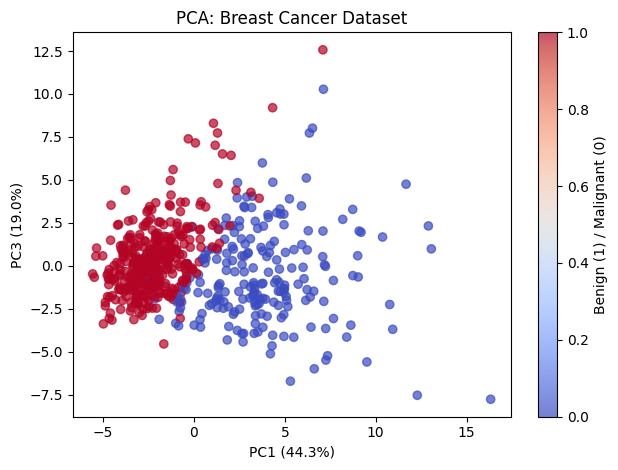

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale and apply PCA
X_scaled = StandardScaler().fit_transform(X) # Data preprocessing
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=data.target, cmap='coolwarm', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: Breast Cancer Dataset')
plt.colorbar(label='Benign (1) / Malignant (0)')
plt.tight_layout()

## **Exercise 3:** Generating and Visualizing Text Embeddings

### Task Description
Generate text embeddings for question-answer pairs and visualize them in 2D to observe semantic clustering.

### Instructions

1. Run the code cells in order. Observe how questions and their corresponding answers cluster together in the visualization.

2. **Modify** the Python code!

   **Required modification (choose one):**
   - Sign up for a [**Cohere account**](https://cohere.com/) by clicking [**this link**](https://dashboard.cohere.com/welcome/register) to get a **free API key** and store it as a Colab secret named `COHERE_API_KEY` (or set it as an environment variable if you are working locally). This enables you to generate embeddings for your own text data. Then add at least one new Q&A pair on a biomedical topic of your choice to the `qa_pairs` dictionary (Step 1), and re-run all steps from Step 2 onwards to generate new embeddings and visualize them.
   - **If you do NOT have a Cohere API key**, the code will automatically load pre-generated embeddings for the original 6 Q&A pairs. In this case, **do NOT add new Q&A pairs** (the pre-generated embeddings won't match). Instead, **modify the visualization parameters**: try changing `color_by` from `"topic"` to `"type"`, switch between methods (`"umap"`, `"pca"`, `"tsne"`), or adjust parameters like `n_neighbors` or `perplexity`.

3. **Optional:** Compare all three visualization methods (UMAP, PCA, t-SNE) and note which one best separates the topics.

### Learning Objectives
- Understand how text embeddings convert words into numerical vectors that capture semantic meaning
- Observe that similar texts produce similar vectors, enabling search, clustering, and classification
- Practice UMAP visualization, the same technique widely used for analyzing single-cell RNA-seq data
- Compare different dimensionality reduction methods (UMAP, PCA, t-SNE)

### Step 1: Define Q&A Pairs

First, we create question-answer pairs on biomedical topics stored as a dictionary. **Add at least one new entry** following the same format:

In [ ]:
from IPython.display import display, Markdown

qa_pairs = {
    "DNA": {
        "question": "What is an API?",
        "answer": "An API (Application Programming Interface) is a set of rules and tools that allows different software applications to communicate with each other."
    },
    "Antibodies": {
        "question": "What is Annotation?",
        "answer": "An annotation is a note, label, or metadata added to code, data, or documents to provide additional information without affecting the core functionality."
    },
    "Mitochondria": {
        "question": "What is the role of mitochondria in cells?",
        "answer": "Mitochondria are organelles that generate energy for the cell through cellular respiration"
    },
    "Neuron": {
        "question": "What is a neuron?",
        "answer": "A neuron is a specialized cell that transmits nerve impulses in the nervous system"
    },
    "Insulin": {
        "question": "What is the function of insulin?",
        "answer": "Insulin is a hormone that regulates blood glucose levels in the body"
    },
    "Virus": {
        "question": "What is a virus?",
        "answer": "A virus is a microscopic infectious agent that can only replicate inside living cells"
    },
}

for topic, qa in qa_pairs.items():
    display(Markdown(f"**{qa['question']}**  \n{qa['answer']}  \n"))

**What is an API?**  
An API (Application Programming Interface) is a set of rules and tools that allows different software applications to communicate with each other.  


**What is Annotation?**  
An annotation is a note, label, or metadata added to code, data, or documents to provide additional information without affecting the core functionality.  


**What is the role of mitochondria in cells?**  
Mitochondria are organelles that generate energy for the cell through cellular respiration  


**What is a neuron?**  
A neuron is a specialized cell that transmits nerve impulses in the nervous system  


**What is the function of insulin?**  
Insulin is a hormone that regulates blood glucose levels in the body  


**What is a virus?**  
A virus is a microscopic infectious agent that can only replicate inside living cells  


### Step 2: Data Preparation

Extract questions and answers into a flat list for the embedding API:

In [ ]:
texts = [qa["question"] for topic, qa in qa_pairs.items()] + \
        [qa["answer"] for topic, qa in qa_pairs.items()]
texts

['What is an API?',
 'What is Annotation?',
 'What is the role of mitochondria in cells?',
 'What is a neuron?',
 'What is the function of insulin?',
 'What is a virus?',
 'An API (Application Programming Interface) is a set of rules and tools that allows different software applications to communicate with each other.',
 'An annotation is a note, label, or metadata added to code, data, or documents to provide additional information without affecting the core functionality.',
 'Mitochondria are organelles that generate energy for the cell through cellular respiration',
 'A neuron is a specialized cell that transmits nerve impulses in the nervous system',
 'Insulin is a hormone that regulates blood glucose levels in the body',
 'A virus is a microscopic infectious agent that can only replicate inside living cells']

### Step 3: Generate Embeddings

Generate embeddings via Cohere API, with fallback to pre-generated data. See [Cohere Embed API docs](https://docs.cohere.com/reference/embed) for details.

> ⚠️ **Important:** If you don't have a Cohere API key, the code below will load pre-generated embeddings for the **original 6 Q&A pairs only**. If you added new Q&A pairs in Step 1 without a key, the number of texts and embeddings will not match and the code will fail. In that case, either remove your additions and modify visualization parameters instead (see Instructions above), or sign up for a free key at [cohere.com](https://cohere.com).

In [ ]:
import cohere, os, httpx
EMBEDDINGS_URL = "https://gist.githubusercontent.com/nicomarr/731745d00275c1fde321b77a8e2b34b8/raw/qa_embeddings_combined.json"

try:
    embeddings = cohere.Client(os.environ.get('COHERE_API_KEY')).embed(
        texts=texts, model="embed-english-v3.0", input_type="clustering").embeddings
    print(f"✓ Generated {len(embeddings)} embeddings via Cohere API")
except:
    data = httpx.get(EMBEDDINGS_URL).json()
    embeddings = data['embeddings']
    print(f"✓ Loaded {len(embeddings)} pre-generated embeddings")

✓ Loaded 12 pre-generated embeddings


### Step 4: Inspect Embeddings

Each embedding is a 1024-dimensional vector. Here are the first few elements:

In [ ]:
print(f"Embedding dimension: {len(embeddings[0])}")
print(f"First 4 elements of each embedding:")
for e in embeddings:
    print(f"{e[:4]}")

Embedding dimension: 1024
First 4 elements of each embedding:
[-0.034088135, -0.03414917, -0.07849121, -0.039398193]
[0.009506226, 0.0005674362, 0.0020980835, -0.016693115]
[-0.019210815, -0.016052246, 0.011726379, 0.013580322]
[0.0016527176, -0.02192688, 0.009346008, 0.017227173]
[-0.010047913, 0.0051841736, -0.019821167, 0.017318726]
[0.005542755, -0.014587402, -0.03363037, -0.04421997]
[-0.08441162, -0.03665161, -0.050872803, -0.030090332]
[0.027496338, 0.014907837, -0.0005607605, -0.032196045]
[-0.024047852, -0.03857422, 0.04119873, 0.034423828]
[0.021255493, -0.0067100525, 0.048950195, -0.008323669]
[-0.023010254, 0.0071411133, 0.0031223297, 0.0014238358]
[0.007598877, -0.008033752, 0.01008606, -0.01675415]


### Step 5: Prepare data for visualization

Create a DataFrame with text, type (question/answer), and topic labels:

In [ ]:
import pandas as pd
sentences = pd.DataFrame({'text': texts,
                         'type': ['question']*6 + ['answer']*6,
                         'topic': list(qa_pairs.keys())*2})

### Step 6: Visualize embeddings

Finally, we use UMAP to reduce dimensions and create an interactive visualization (Note: you would use a similar approach to visualize single cell RNA-seq data):

In [ ]:
embed_utils.visualize_embeddings(
    sentences, embeddings, method="umap",
    umap_params={"n_neighbors": 2}, color_by="type"
).interactive()

alt.Chart(...)

For comarison, we can also visualize using PCA:

In [ ]:
embed_utils.visualize_embeddings(
    sentences, embeddings, method="pca",
    umap_params={"n_neighbors": 2}, color_by="type"
).interactive()

alt.Chart(...)

 Alternatively, we can use t-SNE:

In [ ]:
embed_utils.visualize_embeddings(
    sentences, embeddings, method="tsne",
    tsne_params={"perplexity": 3}, color_by="type"
).interactive()

alt.Chart(...)

**Note:** UMAP (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique that preserves both local and global structure in high-dimensional data. It's particularly well-suited for visualizing text embeddings.

**Comparison with other methods:**
- **PCA**: Faster and simpler, but only captures linear relationships
- **t-SNE**: Better at preserving local clusters, but slower and may distort global structure
- **UMAP**: Balances speed and structure preservation, though it requires careful parameter tuning

**Mini-task:** Run all three methods (UMAP, PCA, t-SNE) and compare the plots. Which one most clearly separates the question-answer pairs by topic?

### Step 7: Explore the function

Use Jupyter's `?` syntax to view the function signature, parameters, and usage examples:

**Try this:** After viewing the signature, change `color_by="topic"` to `color_by="type"` in one of the visualization calls above and re-run it. What does the visualization show now?

In [ ]:
embed_utils.visualize_embeddings?

## **Exercise 4:** Similarity Search on Text Embeddings

### Task Description
Use cosine similarity to find semantically related texts from a collection of embeddings.

### Instructions
1. **Run the code cells as is**, to see similarity search in action using the embeddings from Exercise 3.
   
2. **Modify the code cells** by choosing at least one of the following options:
   
   - **Option 1 (easy):** In Step 2, choose your own pair of texts from the list (by changing the index numbers) and compute their cosine distance. Pick a pair you think will be very similar and a pair you think will be dissimilar. Were you right?
   
   - **Option 2 (medium):** In Step 3 (requires Cohere API key), change the query text to a question related to your own research area and observe which texts are retrieved.
   
   - **Option 3 (challenging):** Replace the question and answer pairs with titles and abstracts from your own research area, and change the query text in step 3 to a question related to these papers. This will require you to generate new embeddings for your dataset (see Exercise 3) and then perform similarity search on those embeddings. This is how RAG (Retrieval-Augmented Generation) systems work in practice!

> **No Cohere API key?** You can still complete this exercise by modifying the cosine distance comparisons in Step 2. The similarity search in Step 3 requires a key to embed new queries.

### Learning Objectives
- Understand that cosine similarity measures how similar two vectors are (1.0 = identical, 0.0 = unrelated)
- Experience how similarity search powers semantic search engines and recommendation systems
- Connect the dot product from Exercise 1 to a real application: cosine distance uses the dot product of normalized vectors

### View Source Code
Since dynamically loaded functions don't display source with `?`, view the full implementation in the [GitHub gist](https://gist.github.com/nicomarr/9445da5f2a1be55c406899ad3a5356a7).

### Step 1: Load Data

If running this exercise independently, the cell below loads the Q&A pairs and embeddings from a gist:

In [ ]:
import numpy as np, httpx

if 'texts' not in dir():
    data = httpx.get("https://gist.githubusercontent.com/nicomarr/731745d00275c1fde321b77a8e2b34b8/raw/qa_embeddings_combined.json").json()
    texts = [qa["question"] for qa in data['qa_pairs'].values()] + [qa["answer"] for qa in data['qa_pairs'].values()]
    embeddings = data['embeddings']
    print(f"✓ Loaded {len(texts)} texts and embeddings from gist")
else:
    print(f"✓ Using {len(texts)} texts and embeddings from Exercise 3")

embeddings_array = np.array(embeddings, dtype=np.float64)

✓ Using 12 texts and embeddings from Exercise 3


### Step 2: Compare Two Texts with Cosine Distance

Cosine distance uses the dot product (from Exercise 1) to measure similarity between vectors. Lower distance = more similar.

**Your task:** After running the cell below, try changing the index numbers to compare different text pairs. For the original 6 Q&A pairs, texts are indexed 0–11 (questions 0–5, answers 6–11). If you added Q&A pairs in Exercise 3, run `list(enumerate(texts))` to see all available texts and their indices.

In [ ]:
# Similar pair: question and its answer
similar_dist = embed_utils.cosine_distance(embeddings_array[2], embeddings_array[4])
print(f"Similar pair (distance: {similar_dist:.3f}):\n  Q: '{texts[2]}'\n  A: '{texts[4]}'\n")

# Dissimilar pair: unrelated question and answer
dissimilar_dist = embed_utils.cosine_distance(embeddings_array[1], embeddings_array[6])
print(f"Dissimilar pair (distance: {dissimilar_dist:.3f}):\n  Q: '{texts[1]}'\n  A: '{texts[6]}'")

Similar pair (distance: 0.511):
  Q: 'What is the role of mitochondria in cells?'
  A: 'What is the function of insulin?'

Dissimilar pair (distance: 0.634):
  Q: 'What is Annotation?'
  A: 'An API (Application Programming Interface) is a set of rules and tools that allows different software applications to communicate with each other.'


### Step 3: Search for Similar Texts

For searching through many texts, we use `find_closest_matches()` which applies cosine distance across the entire corpus.

**Note:** This step requires a Cohere API key to embed the query. Sign up free at [cohere.com](https://cohere.com). If you don't have a key, you can skip this step — your Exercise 4 completion will be based on Step 2 modifications.

**Your task:** If you have a key, change the `query` variable below to a question from your own field and see which texts are retrieved.

In [ ]:
import warnings
import os
import numpy as np

warnings.filterwarnings("ignore")

try:
    import cohere
except ImportError:
    print("Installing cohere library...")
    import subprocess
    subprocess.check_call(['pip', 'install', '--break-system-packages', 'cohere'])
    import cohere


# ============================================================================
# STEP 1: Define sample corpus (replace with your actual documents)
# ============================================================================
texts = [
    "COVID-19 vaccination is one of the most effective public health interventions.",
    "Common side effects of COVID-19 vaccines include mild fever and arm soreness.",
    "Serious adverse effects of COVID-19 vaccination are extremely rare but can include myocarditis.",
    "Most COVID-19 vaccine recipients experience no side effects at all.",
    "The benefits of COVID-19 vaccination far outweigh the risks for the vast majority of people.",
    "Myocarditis and pericarditis are rare inflammatory heart conditions reported after mRNA vaccination.",
]

# ============================================================================
# STEP 2: Define helper function to find closest matches
# ============================================================================
def find_closest_matches(query_embedding, embeddings_array, top_k=3):
    """
    Find top_k closest matches using cosine distance

    Args:
        query_embedding: 1D numpy array of query embedding
        embeddings_array: 2D numpy array of document embeddings
        top_k: number of top matches to return

    Returns:
        indices: array of shape [1, top_k] with document indices
        distances: array of shape [1, top_k] with cosine distances
    """
    # Normalize vectors for cosine distance
    query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-8)
    embeddings_norm = embeddings_array / (np.linalg.norm(embeddings_array, axis=1, keepdims=True) + 1e-8)

    # Compute cosine distances (1 - cosine_similarity)
    cosine_distances = 1 - np.dot(embeddings_norm, query_norm)

    # Get top_k indices sorted by distance (closest first)
    top_indices = np.argsort(cosine_distances)[:top_k]
    top_distances = cosine_distances[top_indices]

    return np.array([top_indices]), np.array([top_distances])


# ============================================================================
# STEP 3: Main execution
# ============================================================================

query = "what are some serious adverse effects of covid-19 vaccination?"

print("=" * 80)
print("COHERE SEMANTIC SEARCH - CORRECTED VERSION")
print("=" * 80)
print(f"\nCorpus: {len(texts)} documents")
print(f"Query: '{query}'\n")

try:
    # Get API key from environment
    api_key = os.environ.get('COHERE_API_KEY')

    if not api_key:
        raise ValueError("COHERE_API_KEY environment variable not set")

    # Initialize Cohere client with valid API key
    client = cohere.Client(api_key)

    # Get embedding for query
    print("Embedding query with Cohere API...")
    query_embedding = np.array(
        client.embed(
            texts=[query],
            model="embed-english-v3.0",
            input_type="search_query"
        ).embeddings[0]
    )
    print(f"✓ Query embedding generated (dimension: {len(query_embedding)})")

    # Get embeddings for all documents
    print("Embedding corpus documents...")
    embeddings_response = client.embed(
        texts=texts,
        model="embed-english-v3.0",
        input_type="search_document"
    )
    embeddings_array = np.array(embeddings_response.embeddings)
    print(f"✓ Corpus embeddings generated (shape: {embeddings_array.shape})")

    # Find closest matches
    print("\nSearching for similar documents...")
    indices, distances = find_closest_matches(query_embedding, embeddings_array, top_k=3)

    # Display results
    print("\nTop 3 matches (by cosine distance):\n")
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
        print(f"{rank}. (distance: {dist:.4f})")
        print(f"   → {texts[idx]}\n")

except ValueError as e:
    # Handle missing API key
    print(f"❌ Configuration Error: {e}")
    print("\nTo use this code with Cohere API:")
    print("1. Get your free API key from: https://cohere.com/")
    print("2. Set the environment variable:")
    print("   export COHERE_API_KEY='your-actual-key'")
    print("3. Run the script again\n")

    # Demo mode with random embeddings
    print("Running in DEMO MODE (using random embeddings)...\n")
    query_embedding = np.random.randn(1024)
    embeddings_array = np.random.randn(len(texts), 1024)

    indices, distances = find_closest_matches(query_embedding, embeddings_array, top_k=3)

    print(f"Top 3 matches (demo with random embeddings):\n")
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
        print(f"{rank}. (distance: {dist:.4f})")
        print(f"   → {texts[idx]}\n")

except Exception as e:
    # Handle other errors
    error_msg = str(e)
    if hasattr(e, 'body'):
        error_msg = getattr(e.body, 'get', lambda x: str(e))('message', str(e))

    print(f"❌ Error: {error_msg}")
    print("\nTroubleshooting:")
    print("• Check your API key is valid and has available credits")
    print("• Verify network connectivity")
    print("• Check API rate limits")

print("=" * 80)


COHERE SEMANTIC SEARCH - CORRECTED VERSION

Corpus: 6 documents
Query: 'what are some serious adverse effects of covid-19 vaccination?'

❌ Configuration Error: COHERE_API_KEY environment variable not set

To use this code with Cohere API:
1. Get your free API key from: https://cohere.com/
2. Set the environment variable:
   export COHERE_API_KEY='your-actual-key'
3. Run the script again

Running in DEMO MODE (using random embeddings)...

Top 3 matches (demo with random embeddings):

1. (distance: 0.9785)
   → Serious adverse effects of COVID-19 vaccination are extremely rare but can include myocarditis.

2. (distance: 0.9794)
   → Myocarditis and pericarditis are rare inflammatory heart conditions reported after mRNA vaccination.

3. (distance: 0.9825)
   → COVID-19 vaccination is one of the most effective public health interventions.



## Additional Resources

- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html): Comprehensive guide to using scikit-learn for machine learning tasks.
- [UMAP Documentation](https://umap-learn.readthedocs.io/): Learn more about UMAP parameters and use cases.
- [Cohere Embed API](https://docs.cohere.com/reference/embed): Documentation for generating text embeddings with Cohere.
- [Agents.md](https://agents.md/): A community effort and simple, open format for guiding coding agents.
- [Prompts for Data Science](https://gist.github.com/nicomarr/04387921552b179e4b18a49820254891): Example prompts for tackling various data analysis problems. Feel free to use and modify them for your specific use case.

---

## License

This notebook is licensed under [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/).

Copyright © 2026 onwards Nico Marr

You are free to share and adapt this material for non-commercial purposes with appropriate attribution. For commercial licensing inquiries, contact: nico.marr@tuta.com